In [ ]:
%pip install xarray

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [12]:
# STEP 1: LOAD ALL IMD FILES
# ============================================================
def load_imd(path_pattern: str, y1: int = 1981, y2: int = 2023) -> xr.Dataset:
    """
    Load all IMD NetCDF files matching pattern.
    Lazy loading — won't crash RAM.
    """
    ds = xr.open_mfdataset(
        path_pattern,          # e.g. "data/raw/imd_rainfall/RF25_ind*.nc"
        combine='by_coords',
        engine='netcdf4'
    )
    # Slice years
    ds = ds.sel(time=slice(f'{y1}-01-01', f'{y2}-12-31'))
    print(f"Shape: {ds.dims}")
    print(f"Variables: {list(ds.data_vars)}")
    # IMD variable name is usually 'rf' or 'RAINFALL'
    # Check with: print(ds)
    ds = ds.rename({
    "TIME":"time",
    "LATITUDE":"lat",
    "LONGITUDE":"lon",
    "RAINFALL":"rf"
})

    return ds


In [13]:
# STEP 2: COMPUTE RAINFALL FEATURES (all from IMD only)
# ============================================================
def compute_features(ds: xr.Dataset, rain_var: str = 'rf') -> pd.DataFrame:
    """
    Engineer all features from raw daily rainfall.
    Returns one row per grid cell (lat, lon) with temporal stats.
    """
    rain = ds[rain_var]  # shape: (time, lat, lon)

    # --- Annual total ---
    annual = rain.resample(time='1Y').sum()

    # --- Monsoon (JJAS) total ---
    monsoon_mask = rain.time.dt.month.isin([6, 7, 8, 9])
    monsoon = rain.sel(time=monsoon_mask).resample(time='1Y').sum()

    # --- Monsoon Concentration Index (MCI) ---
    # High MCI = rain concentrated in few months = flash flood risk = LOW sponge
    mci = monsoon / (annual + 1e-6)

    # --- Long-term means ---
    mean_annual    = annual.mean('time')
    mean_monsoon   = monsoon.mean('time')
    mean_mci       = mci.mean('time')

    # --- Interannual variability ---
    std_annual = annual.std('time')
    cv = std_annual / (mean_annual + 1e-6)  # Coefficient of variation

    # --- Dry spell proxy ---
    # Count days with < 1mm rain (annual mean)
    dry_days = (rain < 1.0).resample(time='1Y').sum().mean('time')

    # --- Extreme rainfall proxy ---
    # Mean count of days with > 100mm (heavy rain events)
    heavy_days = (rain > 100.0).resample(time='1Y').sum().mean('time')

    # --- Stack to DataFrame ---
    lats, lons = np.meshgrid(ds.lat.values, ds.lon.values, indexing='ij')
    df = pd.DataFrame({
        'lat':            lats.ravel(),
        'lon':            lons.ravel(),
        'mean_annual_rf': mean_annual.values.ravel(),
        'mean_monsoon_rf':mean_monsoon.values.ravel(),
        'mci':            mean_mci.values.ravel(),
        'cv':             cv.values.ravel(),
        'dry_days':       dry_days.values.ravel(),
        'heavy_days':     heavy_days.values.ravel(),
        'std_annual':     std_annual.values.ravel(),
    })

    # Drop NaN (ocean/masked cells)
    df = df.dropna().reset_index(drop=True)
    print(f"Feature matrix: {df.shape}")
    return df


In [15]:
# ============================================================
# STEP 3: EDA PLOTS
# ============================================================
def plot_spatial_map(df: pd.DataFrame, col: str, title: str,
                     cmap: str = 'YlGnBu', save: str = None):
    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(
        df['lon'], df['lat'], c=df[col], cmap=cmap,
        s=10, vmin=df[col].quantile(0.01), vmax=df[col].quantile(0.99)
    )
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_correlation_matrix(df: pd.DataFrame, feature_cols: list, save: str = None):
    corr = df[feature_cols].corr(method='spearman')  # Spearman for skewed data
    fig, ax = plt.subplots(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
    ax.set_title('Spearman Correlation Matrix', fontsize=13)
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()


def plot_annual_trend(ds: xr.Dataset, rain_var: str = 'rf', save: str = None):
    annual_mean = ds[rain_var].resample(time='1Y').sum().mean(['lat', 'lon'])
    years  = annual_mean.time.dt.year.values
    values = annual_mean.values
    rolling = pd.Series(values, index=years).rolling(10, center=True).mean()
    slope, intercept, r, p, _ = stats.linregress(years, values)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(years, values, color='steelblue', alpha=0.4, label='Annual')
    ax.plot(years, rolling, color='darkblue', lw=2, label='10-yr rolling mean')
    ax.plot(years, slope * years + intercept, 'r--', lw=1.5,
            label=f'Trend: {slope:.2f} mm/yr (p={p:.3f})')
    ax.set_xlabel('Year'); ax.set_ylabel('mm')
    ax.set_title('India Mean Annual Rainfall Trend')
    ax.legend(); plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    return slope, p


In [16]:
# USAGE
# ============================================================
if __name__ == '__main__':
    ds = xr.open_dataset(
    "../data/raw/imd_rainfall/RF25_ind2024_rfp25.nc"
)

    df = compute_features(ds, rain_var='rf')  # change 'rf' if your var is named differently

    FEATURES = ['mean_annual_rf', 'mean_monsoon_rf', 'mci', 'cv', 'dry_days',
                'heavy_days', 'std_annual']

    plot_spatial_map(df, 'mean_annual_rf', 'Mean Annual Rainfall (1981-2023)',
                     save='reports/figures/mean_annual_rf.png')
    plot_spatial_map(df, 'mci', 'Monsoon Concentration Index',
                     cmap='Reds', save='reports/figures/mci.png')
    plot_spatial_map(df, 'cv', 'Rainfall Coefficient of Variation',
                     cmap='OrRd', save='reports/figures/cv.png')
    plot_correlation_matrix(df, FEATURES, save='reports/figures/corr_matrix.png')
    plot_annual_trend(ds, save='reports/figures/trend.png')

    df.to_parquet('data/processed/feature_matrix.parquet', index=False)
    print("Saved feature matrix.")

KeyError: "No variable named 'rf'. Variables on the dataset include ['LONGITUDE', 'LATITUDE', 'TIME', 'RAINFALL']"

In [5]:
pip install netCDF4

Note: you may need to restart the kernel to use updated packages.


In [11]:
import xarray as xr

ds = xr.open_dataset(
    "../data/raw/imd_rainfall/RF25_ind1981_rfp25.nc"
)

print(ds)

<xarray.Dataset> Size: 25MB
Dimensions:    (LONGITUDE: 135, LATITUDE: 129, TIME: 365)
Coordinates:
  * LONGITUDE  (LONGITUDE) float64 1kB 66.5 66.75 67.0 ... 99.5 99.75 100.0
  * LATITUDE   (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 38.0 38.25 38.5
  * TIME       (TIME) datetime64[ns] 3kB 1981-01-01 1981-01-02 ... 1981-12-31
Data variables:
    RAINFALL   (TIME, LATITUDE, LONGITUDE) float32 25MB ...
Attributes:
    history:      FERRET V6.82   20-Feb-26
    Conventions:  CF-1.0


In [6]:
import netCDF4
print(netCDF4.__version__)

1.7.4


In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pip install dask

Note: you may need to restart the kernel to use updated packages.


In [3]:
ds = xr.open_mfdataset(
    "../data/raw/imd_rainfall/*.nc",
    combine="by_coords",
    engine="netcdf4"
)

ds = ds.rename({
    "TIME": "time",
    "LATITUDE": "lat",
    "LONGITUDE": "lon",
    "RAINFALL": "rf"
})

print(ds)

<xarray.Dataset> Size: 992MB
Dimensions:  (time: 14245, lat: 129, lon: 135)
Coordinates:
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * time     (time) datetime64[ns] 114kB 1981-01-01 1981-01-02 ... 2025-12-31
Data variables:
    rf       (time, lat, lon) float32 992MB dask.array<chunksize=(365, 129, 135), meta=np.ndarray>
Attributes:
    history:      FERRET V6.82   20-Feb-26
    Conventions:  CF-1.0


In [4]:
print(ds.rf.shape)

print(ds.time.min().values)
print(ds.time.max().values)

print(ds.rf.min().values)
print(ds.rf.max().values)

(14245, 129, 135)
1981-01-01T00:00:00.000000000
2025-12-31T00:00:00.000000000
0.0
939.44617


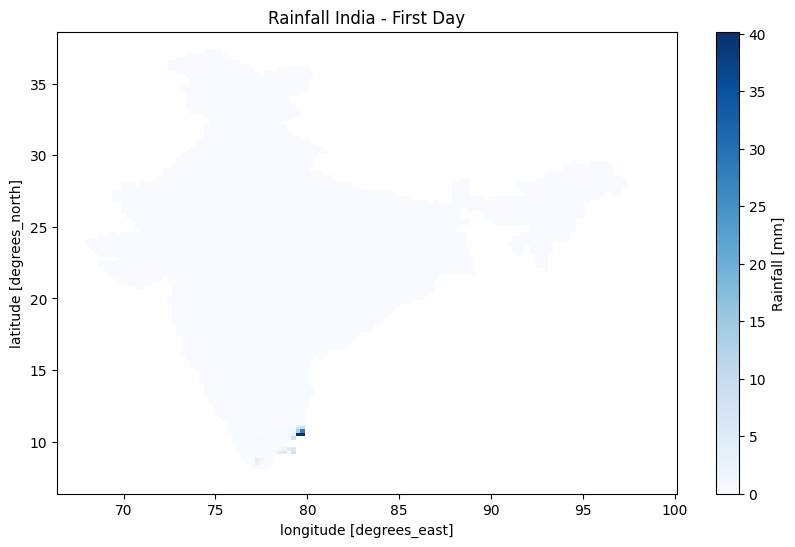

In [5]:
plt.figure(figsize=(10,6))

ds.rf.isel(time=0).plot(
    cmap="Blues"
)

plt.title("Rainfall India - First Day")
plt.show()

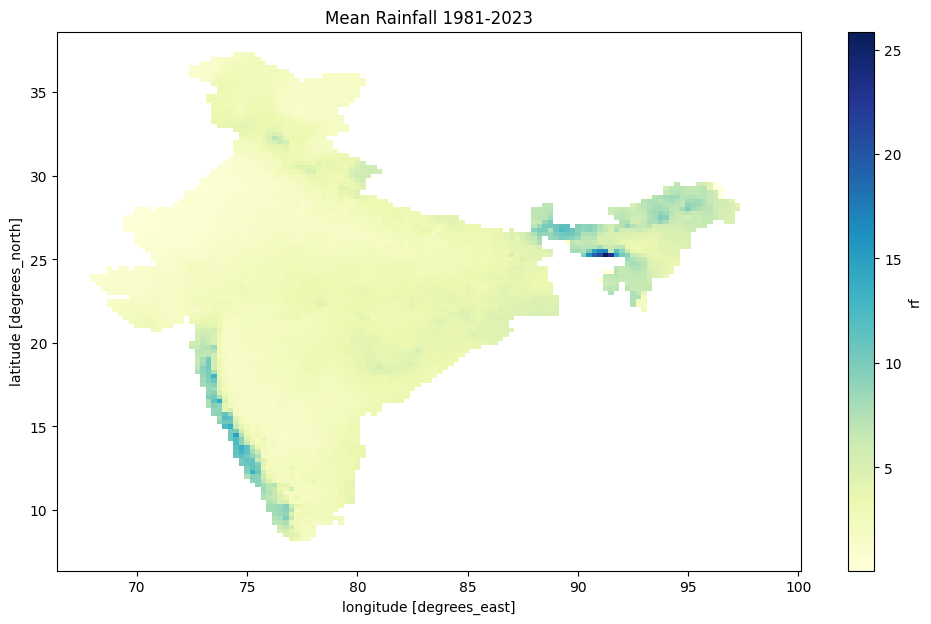

In [6]:
mean_rf = ds.rf.mean(dim="time")

plt.figure(figsize=(12,7))

mean_rf.plot(
    cmap="YlGnBu"
)

plt.title("Mean Rainfall 1981-2023")
plt.show()

In [7]:
annual_rf = ds.rf.resample(
    time="YE"
).sum()

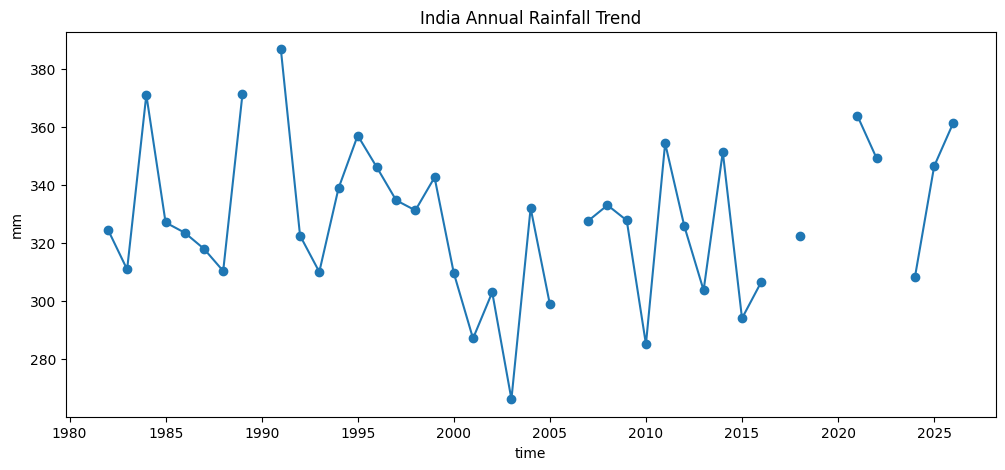

In [8]:
india_mean = annual_rf.mean(
    dim=["lat","lon"]
)

plt.figure(figsize=(12,5))

india_mean.plot(
    marker="o"
)

plt.title("India Annual Rainfall Trend")
plt.ylabel("mm")
plt.show()

In [9]:
annual = ds.rf.resample(time="YE").sum()

mean_annual = annual.mean("time")

std_annual = annual.std("time")

cv = std_annual / (
    mean_annual + 1e-6
)

dry_days = (
    ds.rf < 1
).resample(time="YE").sum().mean("time")

heavy_days = (
    ds.rf > 100
).resample(time="YE").sum().mean("time")

In [10]:
lats,lons = np.meshgrid(
    ds.lat.values,
    ds.lon.values,
    indexing="ij"
)

df = pd.DataFrame({
    "lat": lats.ravel(),
    "lon": lons.ravel(),
    "mean_annual_rf": mean_annual.values.ravel(),
    "std_annual": std_annual.values.ravel(),
    "cv": cv.values.ravel(),
    "dry_days": dry_days.values.ravel(),
    "heavy_days": heavy_days.values.ravel()
})

df = df.dropna()

print(df.shape)

df.head()

(17415, 7)


,lat,lon,mean_annual_rf,std_annual,cv,dry_days,heavy_days
0,6.5,66.50,0.0,0.0,0.0,0.0,0.0
1,6.5,66.75,0.0,0.0,0.0,0.0,0.0
2,6.5,67.00,0.0,0.0,0.0,0.0,0.0
3,6.5,67.25,0.0,0.0,0.0,0.0,0.0
4,6.5,67.50,0.0,0.0,0.0,0.0,0.0


In [12]:
pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 1.6 MB/s eta 0:00:0000:0100:02
Note: you may need to restart the kernel to use updated packages.


In [18]:
df = pd.read_csv(
    "../data/processed/feature_matrix.csv"
)

df = df[
    df["mean_annual_rf"] > 0
].reset_index(drop=True)

print(df.shape)

(4964, 7)


In [19]:
df.to_csv(
    "../data/processed/feature_matrix.csv",
    index=False
)

In [20]:
print(df.shape)

print(df["mean_annual_rf"].min())
print(df["mean_annual_rf"].max())

(4964, 7)
23.241503
9444.708


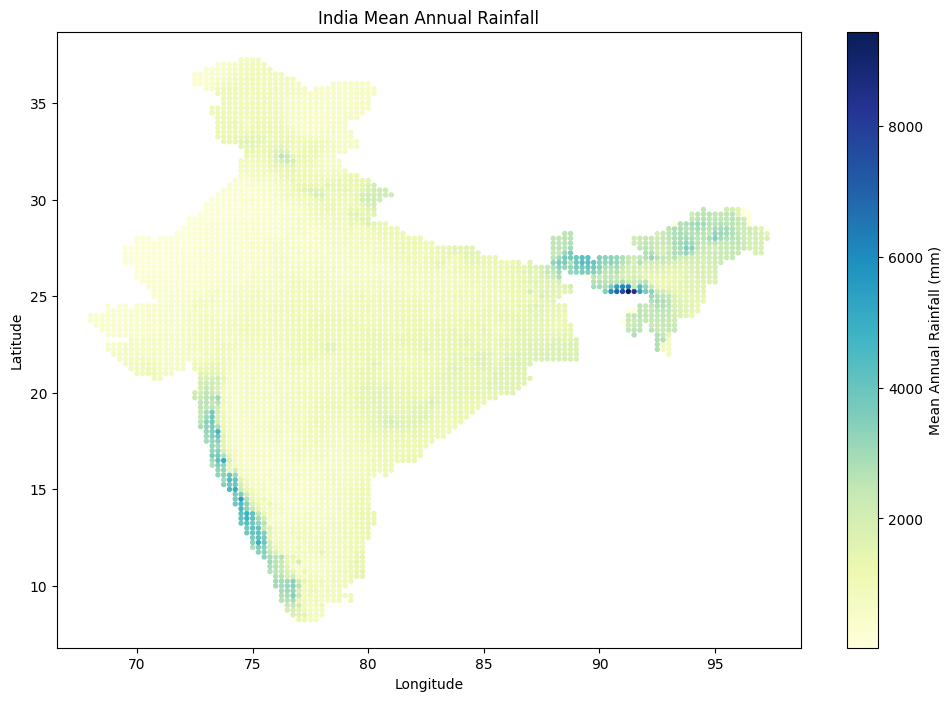

In [21]:
plt.figure(figsize=(12,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["mean_annual_rf"],
    s=8,
    cmap="YlGnBu"
)

plt.colorbar(label="Mean Annual Rainfall (mm)")
plt.title("India Mean Annual Rainfall")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()